# 🏥 MedNova AI — Semaine 5
## Module BI : KPIs · Agrégations · Prévisions ARIMA

> **Kernel → Restart & Run All** pour exécuter tout

## Section init

In [23]:
# ══════════════════════════════════════════════════════════════════════════════
#  MedNova AI — Semaine 5
#  Module BI : KPIs · Agrégations · Prévisions (Forecasting)
#  ✅ Exécuter : python bi_aggregator.py
# ══════════════════════════════════════════════════════════════════════════════

# ─────────────────────────────────────────────────────────────────────────────

## ⚙️ Section 0 — Installation automatique

In [25]:
# SECTION 0 : Installation automatique
# ─────────────────────────────────────────────────────────────────────────────
import subprocess, sys

REQUIRED_PKGS = [
    'pandas', 'numpy', 'matplotlib', 'seaborn',
    'scikit-learn', 'joblib', 'ucimlrepo', 'statsmodels'
]
IMPORT_MAP = {
    'scikit-learn': 'sklearn',
}
for pkg in REQUIRED_PKGS:
    import_name = IMPORT_MAP.get(pkg, pkg.replace('-', '_'))
    try:
        __import__(import_name)
    except ImportError:
        print(f'📦 Installation {pkg}...')
        try:
            subprocess.check_call(
                [sys.executable, '-m', 'pip', 'install', pkg, '-q'],
                stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL
            )
            print(f'   ✅ {pkg} installé')
        except subprocess.CalledProcessError:
            print(f'   ⚠️  {pkg} — installer manuellement : pip install {pkg}')

# ─────────────────────────────────────────────────────────────────────────────

## 📦 Section 1 — Imports

In [26]:
# SECTION 1 : Imports
# ─────────────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import json
import time
warnings.filterwarnings('ignore')

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model        import ARIMA
from sklearn.metrics                    import mean_absolute_error

plt.style.use('seaborn-v0_8-whitegrid')

print('✅ Imports OK')

# ─────────────────────────────────────────────────────────────────────────────

✅ Imports OK


## 📁 Section 2 — Chemins

In [27]:
# SECTION 2 : Chemins
# ─────────────────────────────────────────────────────────────────────────────
BASE_DIR    = os.path.abspath(os.path.dirname(__file__) if '__file__' in dir() else os.getcwd())
OUTPUTS_DIR = os.path.abspath(os.path.join(BASE_DIR, '..', 'outputs', 'bi'))
JSON_DIR    = os.path.abspath(os.path.join(BASE_DIR, '..', 'outputs', 'json'))

os.makedirs(OUTPUTS_DIR, exist_ok=True)
os.makedirs(JSON_DIR,    exist_ok=True)

print(f'📁 OUTPUTS_DIR : {OUTPUTS_DIR}')
print(f'📁 JSON_DIR    : {JSON_DIR}')

# ─────────────────────────────────────────────────────────────────────────────

📁 OUTPUTS_DIR : C:\Users\HP\Desktop\ing4\MedNova\MedNova\outputs\bi
📁 JSON_DIR    : C:\Users\HP\Desktop\ing4\MedNova\MedNova\outputs\json


## 📦 Section 3 — Chargement SUPPORT2

In [28]:
# SECTION 3 : Chargement SUPPORT2
# ─────────────────────────────────────────────────────────────────────────────
df          = None
DATA_SOURCE = None

print('\n🔄 Chargement SUPPORT2...')
try:
    from ucimlrepo import fetch_ucirepo
    for attempt in range(3):
        try:
            support2    = fetch_ucirepo(id=880)
            df          = support2.data.original.copy()
            DATA_SOURCE = 'UCI_OFFICIAL'
            print(f'   ✅ UCI OK (tentative {attempt+1})')
            break
        except Exception as e:
            print(f'   ⚠️  Tentative {attempt+1}/3 : {e}')
            if attempt < 2: time.sleep(2)
except ImportError:
    pass

if df is None:
    print('   🔄 Génération synthétique...')
    np.random.seed(42)
    n = 9105
    df = pd.DataFrame({
        'age'      : np.random.normal(60.7, 15.1, n).clip(18, 102),
        'sex'      : np.random.choice(['male','female'], n, p=[0.554, 0.446]),
        'num.co'   : np.random.choice([0,1,2,3,4,5], n, p=[0.40,0.30,0.16,0.08,0.04,0.02]),
        'diabetes' : np.random.binomial(1, 0.18, n),
        'apache3s' : np.random.normal(50.8, 20.4, n).clip(0, 200),
        'surv2md1' : np.random.beta(2.1, 1.9, n),
        'meanbp'   : np.random.normal(79.6, 22.3, n).clip(20, 200),
        'crea'     : np.random.exponential(1.6, n).clip(0.2, 25),
        'alb'      : np.random.normal(3.1, 0.7, n).clip(0.8, 5.5),
        'slos'     : np.random.exponential(7.8, n).clip(1, 200),
        'd.time'   : np.random.exponential(195, n).clip(1, 1825),
        'hospdead' : np.random.binomial(1, 0.318, n),
        'adlp'     : np.random.poisson(2.1, n).clip(0, 7),
        'dzgroup'  : np.random.choice(
            ['ARF/MOSF w/Sepsis','CHF','COPD','Cirrhosis',
             'Colon Cancer','Coma','Lung Cancer','MOSF w/Malig'], n,
            p=[0.22,0.14,0.11,0.08,0.10,0.12,0.10,0.13]),
    })
    logit = (-2.5 + 0.035*(df['age']-60) + 0.55*df['hospdead']
             - 1.90*df['surv2md1'] + 0.18*df['crea'])
    df['death'] = np.random.binomial(1, 1/(1+np.exp(-logit)))
    DATA_SOURCE = 'SYNTHETIC_SUPPORT2'
    print('   ✅ Synthétique OK')

print(f'📦 Dataset : {df.shape} | Source : {DATA_SOURCE}')

# ─────────────────────────────────────────────────────────────────────────────


🔄 Chargement SUPPORT2...
   ✅ UCI OK (tentative 1)
📦 Dataset : (9105, 48) | Source : UCI_OFFICIAL


## ⚙️ Section 4 — Préparation données BI

In [29]:
# SECTION 4 : Préparation des données BI
# ─────────────────────────────────────────────────────────────────────────────
print('\n⚙️  Préparation données BI...')

# ── Variable complication
if 'd.time' in df.columns and 'death' in df.columns:
    df['death_30j'] = ((df['death'] == 1) & (df['d.time'] <= 30)).astype(int)
else:
    df['death_30j'] = df.get('hospdead', pd.Series(0, index=df.index)).astype(int)

if 'hospdead' in df.columns and 'death' in df.columns and 'd.time' in df.columns:
    df['readmission_proxy'] = (
        (df['hospdead'] == 0) & (df['death'] == 1) &
        (df['d.time'] > 30)  & (df['d.time'] <= 180)
    ).astype(int)
else:
    df['readmission_proxy'] = 0

df['complication'] = ((df['death_30j'] == 1) | (df['readmission_proxy'] == 1)).astype(int)
df['succes']       = (df['death_30j'] == 0).astype(int)

# ── Durée de séjour
df['duree_sejour'] = df['slos'].clip(1, 180) if 'slos' in df.columns else pd.Series(7.0, index=df.index)

# ── Coût estimé (proxy : durée × 1200 € + comorbidités × 800 €)
df['cout_estime'] = (df['duree_sejour'] * 1200 + df['num.co'] * 800).round(0)

# ── Tranches d'âge
df['age_group'] = pd.cut(
    df['age'],
    bins  = [0, 40, 55, 65, 75, 120],
    labels= ['<40', '40-55', '55-65', '65-75', '75+']
)

# ── Service simulé (basé sur dzgroup)
SERVICE_MAP = {
    'ARF/MOSF w/Sepsis' : 'Réanimation',
    'CHF'               : 'Cardiologie',
    'COPD'              : 'Pneumologie',
    'Cirrhosis'         : 'Hépato-gastro',
    'Colon Cancer'      : 'Oncologie',
    'Coma'              : 'Neurologie',
    'Lung Cancer'       : 'Oncologie',
    'MOSF w/Malig'      : 'Réanimation',
}
df['service'] = df['dzgroup'].map(SERVICE_MAP).fillna('Autre')

# ── Dates d'admission simulées (SUPPORT2 = 1989-1994)
np.random.seed(42)
start_date = pd.Timestamp('1989-06-01')
end_date   = pd.Timestamp('1994-01-31')
days_range = (end_date - start_date).days
df['admission_date'] = start_date + pd.to_timedelta(
    np.random.randint(0, days_range, len(df)), unit='D'
)
df['mois_admission']  = df['admission_date'].dt.to_period('M')
df['annee_admission'] = df['admission_date'].dt.year

print(f'   ✅ Données BI prêtes')
print(f'   Taux succès      : {df["succes"].mean()*100:.1f}%')
print(f'   Taux complication: {df["complication"].mean()*100:.1f}%')
print(f'   Durée séjour moy : {df["duree_sejour"].mean():.1f} jours')
print(f'   Coût moyen       : {df["cout_estime"].mean():.0f} €')

# ─────────────────────────────────────────────────────────────────────────────


⚙️  Préparation données BI...
   ✅ Données BI prêtes
   Taux succès      : 72.9%
   Taux complication: 43.3%
   Durée séjour moy : 17.7 jours
   Coût moyen       : 22781 €


## 📊 Section 5 — Fonctions KPIs

In [30]:
# SECTION 5 : Fonctions KPIs
# ─────────────────────────────────────────────────────────────────────────────
print('\n📊 Calcul KPIs...')

# ══════════════════════════════════════════════════════════════
def compute_global_kpis(data):
    """
    Calcule les KPIs globaux du dataset.
    Returns: dict avec tous les indicateurs clés
    """
    n = len(data)
    return {
        'n_patients'            : int(n),
        'taux_succes_pct'       : round(data['succes'].mean() * 100, 2),
        'taux_complication_pct' : round(data['complication'].mean() * 100, 2),
        'taux_readmission_pct'  : round(data['readmission_proxy'].mean() * 100, 2),
        'taux_mortalite_hosp_pct': round(data['hospdead'].mean() * 100, 2) if 'hospdead' in data else None,
        'duree_sejour_moy_j'    : round(data['duree_sejour'].mean(), 1),
        'duree_sejour_med_j'    : round(data['duree_sejour'].median(), 1),
        'cout_moyen_eur'        : round(data['cout_estime'].mean(), 0),
        'cout_total_eur'        : round(data['cout_estime'].sum(), 0),
        'age_moyen'             : round(data['age'].mean(), 1),
    }


# ══════════════════════════════════════════════════════════════
def compute_kpis_by_pathologie(data):
    """
    KPIs agrégés par pathologie (dzgroup).
    Returns: list de dicts triés par taux_complication desc
    """
    results = []
    for path, grp in data.groupby('dzgroup'):
        n = len(grp)
        results.append({
            'pathologie'            : str(path),
            'n_patients'            : int(n),
            'pct_total'             : round(n / len(data) * 100, 1),
            'taux_succes_pct'       : round(grp['succes'].mean() * 100, 2),
            'taux_complication_pct' : round(grp['complication'].mean() * 100, 2),
            'duree_sejour_moy_j'    : round(grp['duree_sejour'].mean(), 1),
            'cout_moyen_eur'        : round(grp['cout_estime'].mean(), 0),
            'age_moyen'             : round(grp['age'].mean(), 1),
        })
    return sorted(results, key=lambda x: -x['taux_complication_pct'])


# ══════════════════════════════════════════════════════════════
def compute_kpis_by_service(data):
    """
    KPIs agrégés par service hospitalier.
    Returns: list de dicts
    """
    results = []
    for svc, grp in data.groupby('service'):
        n = len(grp)
        results.append({
            'service'               : str(svc),
            'n_patients'            : int(n),
            'taux_succes_pct'       : round(grp['succes'].mean() * 100, 2),
            'taux_complication_pct' : round(grp['complication'].mean() * 100, 2),
            'duree_sejour_moy_j'    : round(grp['duree_sejour'].mean(), 1),
            'cout_moyen_eur'        : round(grp['cout_estime'].mean(), 0),
        })
    return sorted(results, key=lambda x: -x['taux_complication_pct'])


# ══════════════════════════════════════════════════════════════
def compute_kpis_by_age_group(data):
    """
    KPIs agrégés par tranche d'âge.
    Returns: list de dicts dans l'ordre des tranches
    """
    results = []
    for age_g, grp in data.groupby('age_group', observed=True):
        n = len(grp)
        results.append({
            'age_group'             : str(age_g),
            'n_patients'            : int(n),
            'taux_succes_pct'       : round(grp['succes'].mean() * 100, 2),
            'taux_complication_pct' : round(grp['complication'].mean() * 100, 2),
            'duree_sejour_moy_j'    : round(grp['duree_sejour'].mean(), 1),
            'cout_moyen_eur'        : round(grp['cout_estime'].mean(), 0),
        })
    return results


# ══════════════════════════════════════════════════════════════
def compute_kpis_by_month(data):
    """
    Agrégation mensuelle des KPIs pour le forecasting.
    Returns: DataFrame indexé par mois
    """
    monthly = data.groupby('mois_admission').agg(
        n_patients            = ('complication',  'count'),
        taux_complication     = ('complication',  'mean'),
        taux_succes           = ('succes',        'mean'),
        duree_sejour_moy      = ('duree_sejour',  'mean'),
        cout_moyen            = ('cout_estime',   'mean'),
        taux_readmission      = ('readmission_proxy', 'mean'),
    ).reset_index()

    monthly['mois_admission'] = monthly['mois_admission'].astype(str)
    monthly['taux_complication'] = (monthly['taux_complication'] * 100).round(2)
    monthly['taux_succes']       = (monthly['taux_succes']       * 100).round(2)
    monthly['taux_readmission']  = (monthly['taux_readmission']  * 100).round(2)
    monthly['duree_sejour_moy']  = monthly['duree_sejour_moy'].round(1)
    monthly['cout_moyen']        = monthly['cout_moyen'].round(0)

    return monthly


# ── Calcul
global_kpis  = compute_global_kpis(df)
kpis_path    = compute_kpis_by_pathologie(df)
kpis_service = compute_kpis_by_service(df)
kpis_age     = compute_kpis_by_age_group(df)
monthly_df   = compute_kpis_by_month(df)

print(f'\n📊 KPIs Globaux :')
for k, v in global_kpis.items():
    print(f'   {k:<30} : {v}')

print(f'\n📊 KPIs par Pathologie (top 4) :')
for p in kpis_path[:4]:
    print(f'   {p["pathologie"]:<25} compl={p["taux_complication_pct"]}%  '
          f'durée={p["duree_sejour_moy_j"]}j  coût={p["cout_moyen_eur"]}€')

print(f'\n📊 KPIs par Service :')
for s in kpis_service:
    print(f'   {s["service"]:<20} compl={s["taux_complication_pct"]}%  '
          f'durée={s["duree_sejour_moy_j"]}j')

print(f'\n📊 KPIs par Âge :')
for a in kpis_age:
    print(f'   {a["age_group"]:<8} compl={a["taux_complication_pct"]}%  '
          f'durée={a["duree_sejour_moy_j"]}j')

# ─────────────────────────────────────────────────────────────────────────────


📊 Calcul KPIs...

📊 KPIs Globaux :
   n_patients                     : 9105
   taux_succes_pct                : 72.95
   taux_complication_pct          : 43.25
   taux_readmission_pct           : 16.2
   taux_mortalite_hosp_pct        : 25.92
   duree_sejour_moy_j             : 17.7
   duree_sejour_med_j             : 11.0
   cout_moyen_eur                 : 22781.0
   cout_total_eur                 : 207422000
   age_moyen                      : 62.7

📊 KPIs par Pathologie (top 4) :
   Coma                      compl=73.66%  durée=17.4j  coût=21855.0€
   MOSF w/Malig              compl=69.52%  durée=17.1j  coût=21856.0€
   Lung Cancer               compl=63.0%  durée=8.5j  coût=11405.0€
   Cirrhosis                 compl=44.69%  durée=13.8j  coût=18657.0€

📊 KPIs par Service :
   Neurologie           compl=73.66%  durée=17.4j
   Oncologie            compl=55.77%  durée=9.0j
   Hépato-gastro        compl=44.69%  durée=13.8j
   Réanimation          compl=43.22%  durée=24.2j
   Pneumolo

## 🚨 Section 6 — Seuils d'alerte

In [31]:
# SECTION 6 : Seuils d'alerte
# ─────────────────────────────────────────────────────────────────────────────
print('\n🚨 Vérification seuils d\'alerte...')

ALERT_THRESHOLDS = {
    'taux_complication_pct' : {'warning': 40.0,  'critical': 55.0},
    'taux_mortalite_hosp_pct': {'warning': 25.0, 'critical': 40.0},
    'duree_sejour_moy_j'    : {'warning': 12.0,  'critical': 20.0},
    'taux_readmission_pct'  : {'warning': 15.0,  'critical': 25.0},
    'cout_moyen_eur'        : {'warning': 12000, 'critical': 20000},
}

def check_alerts(kpis_dict, thresholds=ALERT_THRESHOLDS):
    """
    Vérifie les seuils d'alerte sur les KPIs globaux.
    Returns: list de dicts {kpi, valeur, niveau, seuil}
    """
    alerts = []
    for kpi, val in kpis_dict.items():
        if kpi not in thresholds or val is None:
            continue
        thr = thresholds[kpi]
        if val >= thr['critical']:
            niveau = 'CRITIQUE 🔴'
        elif val >= thr['warning']:
            niveau = 'WARNING 🟡'
        else:
            niveau = 'OK 🟢'
        alerts.append({
            'kpi'     : kpi,
            'valeur'  : val,
            'niveau'  : niveau,
            'seuil_warning'  : thr['warning'],
            'seuil_critical' : thr['critical'],
        })
    return alerts

alerts = check_alerts(global_kpis)
print(f'\n   {"KPI":<35} {"Valeur":<12} {"Statut"}')
print(f'   ' + '-'*60)
for a in alerts:
    print(f'   {a["kpi"]:<35} {str(a["valeur"]):<12} {a["niveau"]}')

# ─────────────────────────────────────────────────────────────────────────────


🚨 Vérification seuils d'alerte...

   KPI                                 Valeur       Statut
   ------------------------------------------------------------
   taux_complication_pct               43.25        WARNING 🟡
   taux_readmission_pct                16.2         WARNING 🟡
   taux_mortalite_hosp_pct             25.92        WARNING 🟡
   duree_sejour_moy_j                  17.7         WARNING 🟡
   cout_moyen_eur                      22781.0      CRITIQUE 🔴


## 📈 Section 7 — Forecasting ARIMA

In [32]:
# SECTION 7 : Forecasting ARIMA
# ─────────────────────────────────────────────────────────────────────────────
print('\n📈 Forecasting ARIMA...')

def forecast_kpi(monthly_data, kpi_col, n_forecast=6, model_type='ARIMA'):
    """
    Prévision d'un KPI sur n_forecast mois avec ARIMA.

    Args:
        monthly_data : DataFrame mensuel (output de compute_kpis_by_month)
        kpi_col      : colonne à prévoir (ex: 'taux_complication')
        n_forecast   : nombre de mois à prévoir (3 à 6)
        model_type   : 'ARIMA' ou 'SARIMA'

    Returns:
        dict : {
            'historique'  : valeurs passées,
            'previsions'  : valeurs prévues,
            'conf_int_low': borne inférieure IC 95%,
            'conf_int_high': borne supérieure IC 95%,
            'mois_prevus' : labels des mois futurs,
            'mae'         : erreur absolue moyenne (train),
        }
    """
    series = monthly_data[kpi_col].dropna().values
    n      = len(series)

    if n < 12:
        print(f'   ⚠️  Série trop courte ({n} points) pour {kpi_col}')
        return None

    # Train sur 80%, évaluation sur 20%
    train_size = int(n * 0.8)
    train      = series[:train_size]
    test       = series[train_size:]

    try:
        if model_type == 'SARIMA' and n >= 24:
            model  = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,0,12),
                             enforce_stationarity=False, enforce_invertibility=False)
        else:
            model  = ARIMA(train, order=(2, 1, 1))

        fitted = model.fit()

        # Évaluation MAE sur test set
        test_pred = fitted.forecast(steps=len(test))
        mae       = round(float(mean_absolute_error(test, test_pred)), 4)

        # Refit sur tout le dataset
        if model_type == 'SARIMA' and n >= 24:
            model_full = SARIMAX(series, order=(1,1,1), seasonal_order=(1,1,0,12),
                                 enforce_stationarity=False, enforce_invertibility=False)
        else:
            model_full = ARIMA(series, order=(2, 1, 1))

        fitted_full = model_full.fit()
        forecast    = fitted_full.get_forecast(steps=n_forecast)
        pred_mean   = forecast.predicted_mean
        conf_int    = forecast.conf_int(alpha=0.05)
        # conf_int peut être DataFrame ou ndarray selon la version statsmodels
        if hasattr(conf_int, 'iloc'):
            ci_low  = conf_int.iloc[:, 0].values
            ci_high = conf_int.iloc[:, 1].values
        else:
            ci_arr  = np.array(conf_int)
            ci_low  = ci_arr[:, 0]
            ci_high = ci_arr[:, 1]

        # Générer les labels des mois futurs
        last_period = pd.Period(monthly_data['mois_admission'].iloc[-1], freq='M')
        future_months = [str(last_period + i + 1) for i in range(n_forecast)]

        return {
            'historique'    : [round(float(v), 3) for v in series],
            'previsions'    : [round(float(v), 3) for v in pred_mean],
            'conf_int_low'  : [round(float(v), 3) for v in ci_low],
            'conf_int_high' : [round(float(v), 3) for v in ci_high],
            'mois_historique': list(monthly_data['mois_admission']),
            'mois_prevus'   : future_months,
            'mae'           : mae,
            'model'         : model_type,
            'n_forecast'    : n_forecast,
        }

    except Exception as e:
        print(f'   ⚠️  Erreur {kpi_col} : {e}')
        return None


# ── Calcul des prévisions pour les 3 KPIs principaux
FORECAST_KPIS = [
    ('taux_complication', 'ARIMA', 6),
    ('taux_succes',       'ARIMA', 6),
    ('duree_sejour_moy',  'ARIMA', 3),
]

forecasts = {}
for kpi_col, model_type, n_months in FORECAST_KPIS:
    print(f'   🔄 Prévision {kpi_col} ({n_months} mois)...')
    result = forecast_kpi(monthly_df, kpi_col, n_forecast=n_months, model_type=model_type)
    if result:
        forecasts[kpi_col] = result
        print(f'      ✅ MAE={result["mae"]:.3f} | Prévisions: {result["previsions"]}')

# ─────────────────────────────────────────────────────────────────────────────


📈 Forecasting ARIMA...
   🔄 Prévision taux_complication (6 mois)...
      ✅ MAE=2.801 | Prévisions: [44.073, 43.903, 43.424, 43.401, 43.344, 43.34]
   🔄 Prévision taux_succes (6 mois)...
      ✅ MAE=3.148 | Prévisions: [72.586, 73.281, 72.968, 72.914, 72.926, 72.93]
   🔄 Prévision duree_sejour_moy (3 mois)...
      ✅ MAE=1.050 | Prévisions: [17.522, 17.728, 17.695]


## 🎨 Section 8 — Visualisations BI


📊 Génération des visualisations...


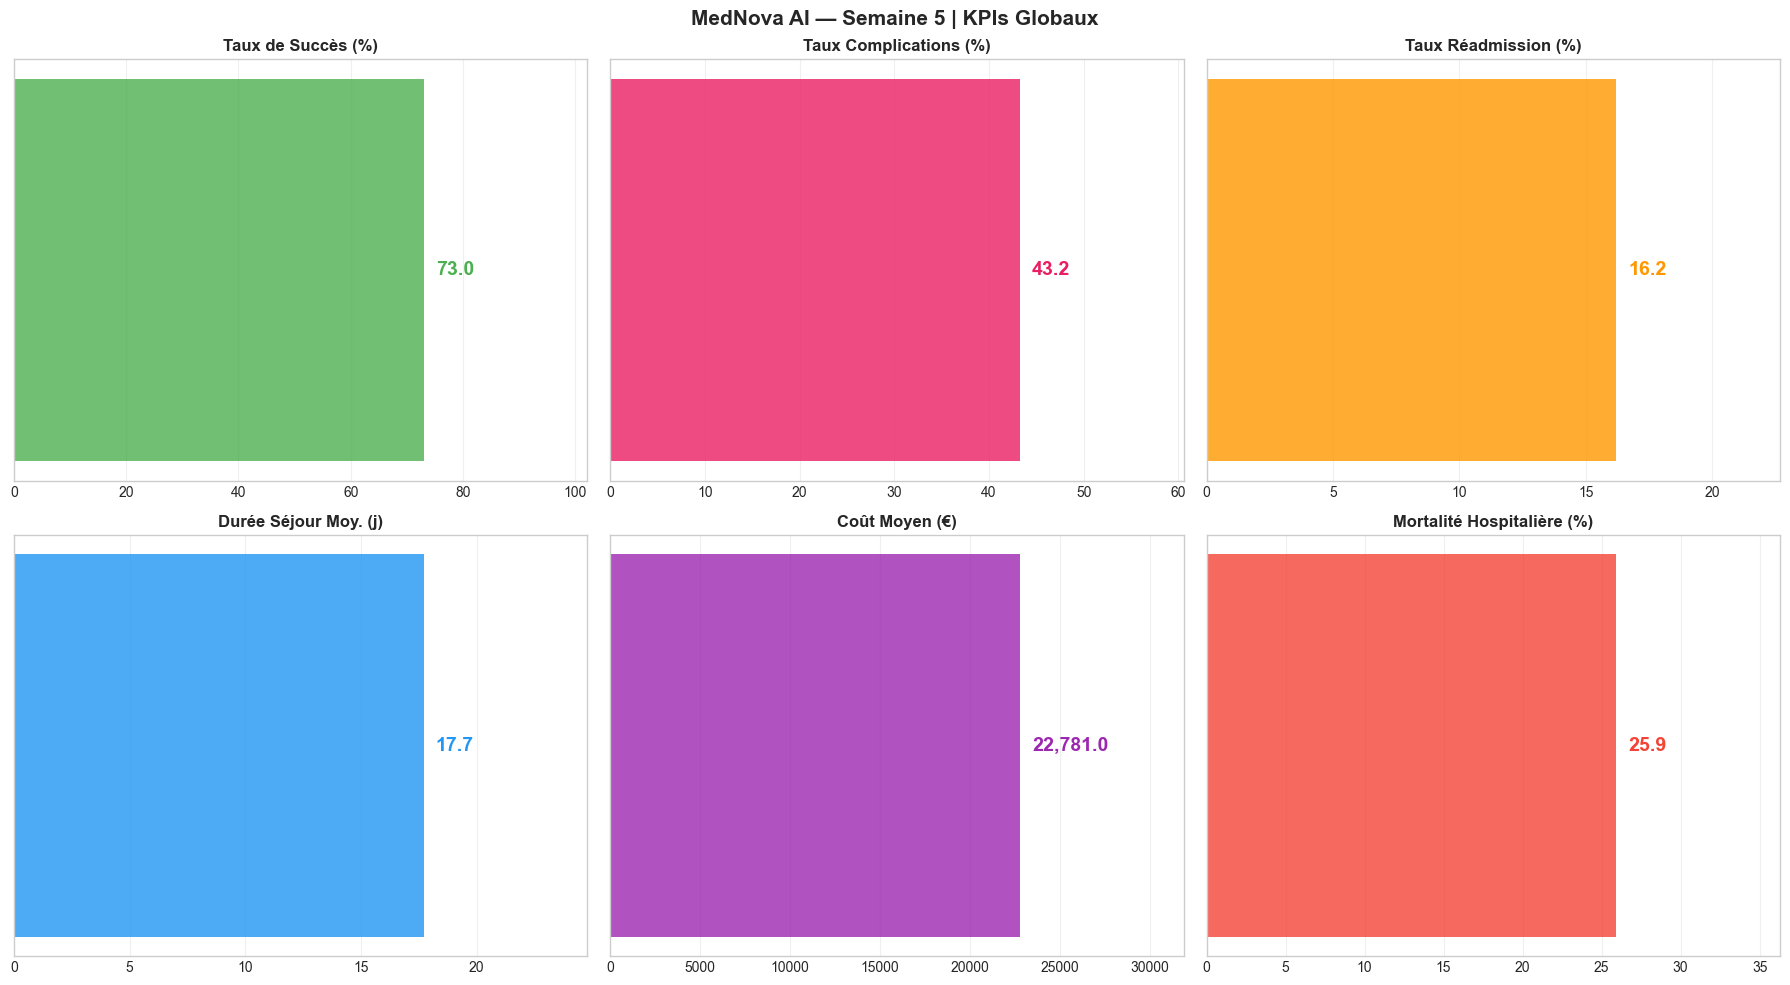

   📊 00_kpis_globaux.png


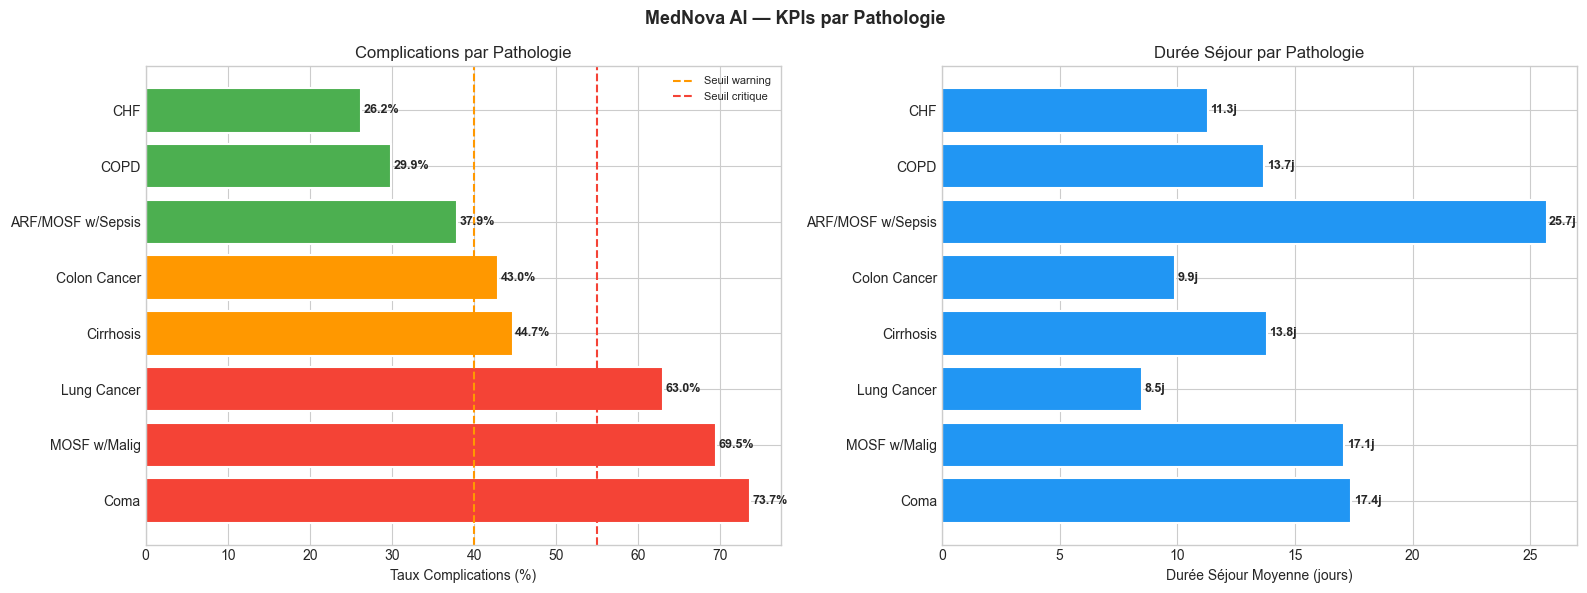

   📊 01_kpis_pathologie.png


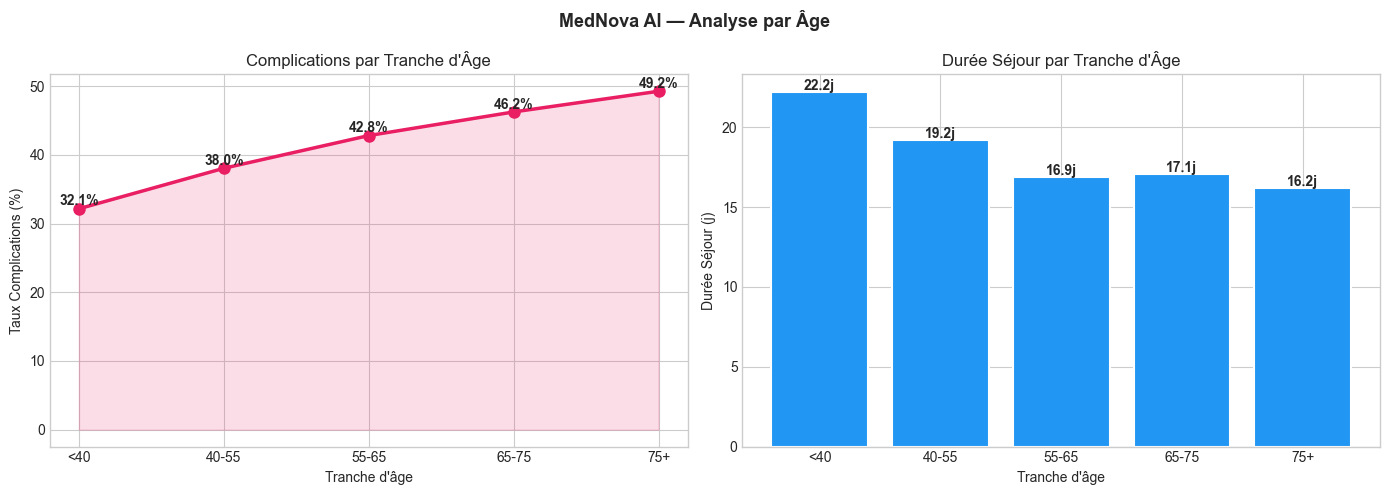

   📊 02_kpis_age.png


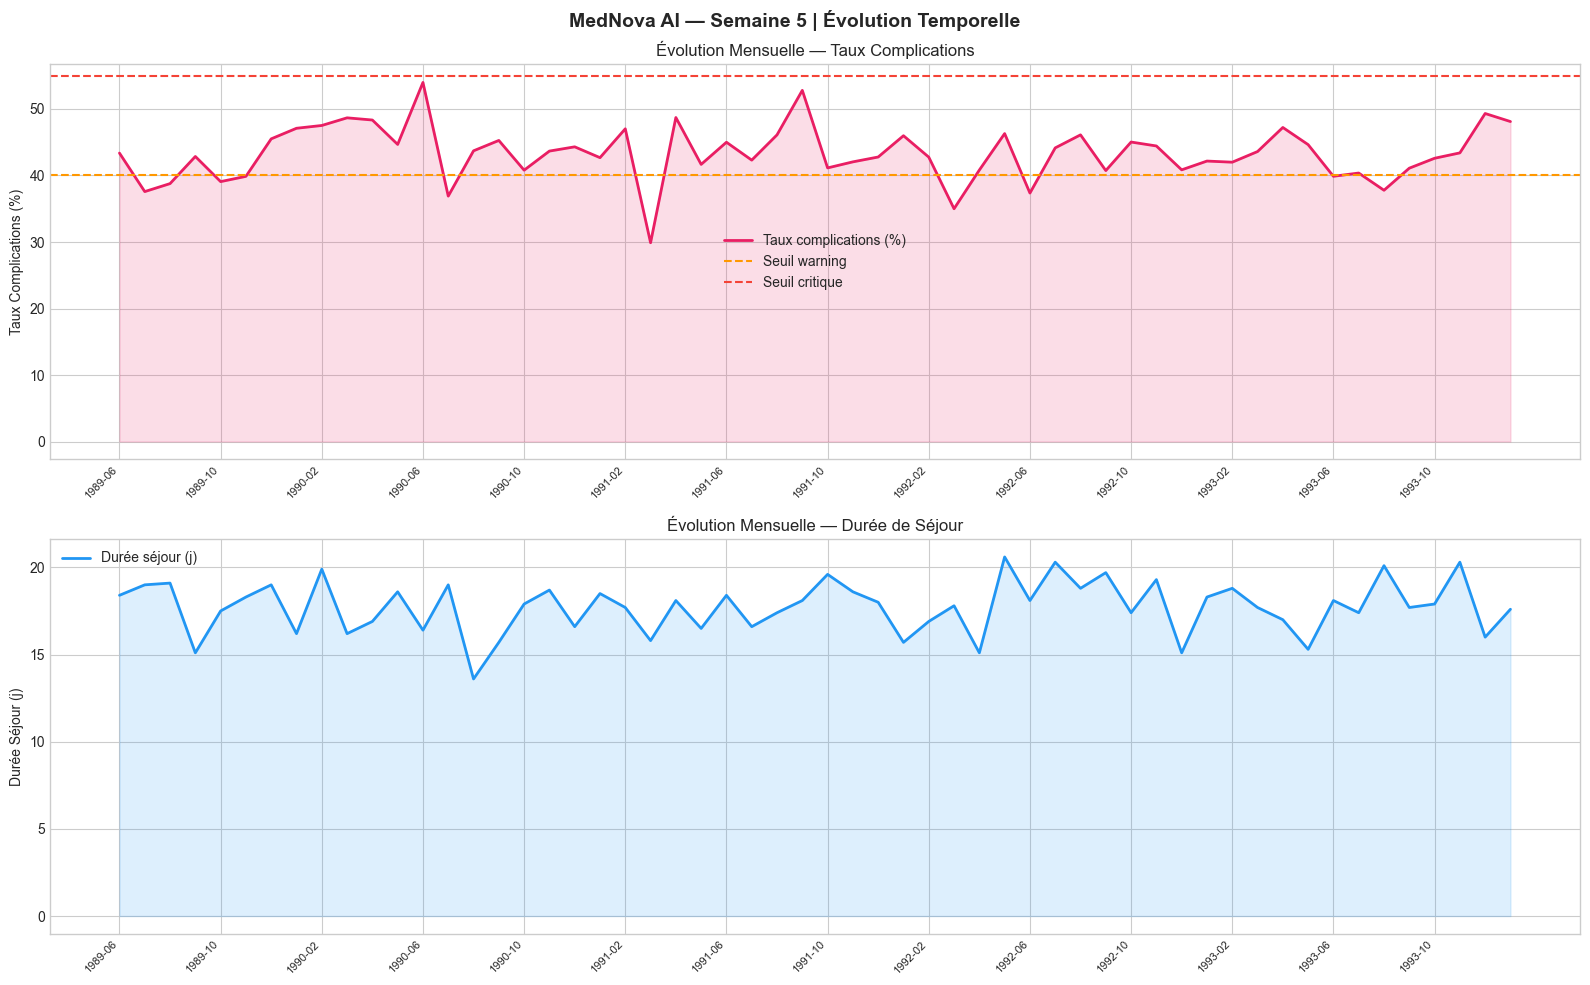

   📊 03_evolution_mensuelle.png


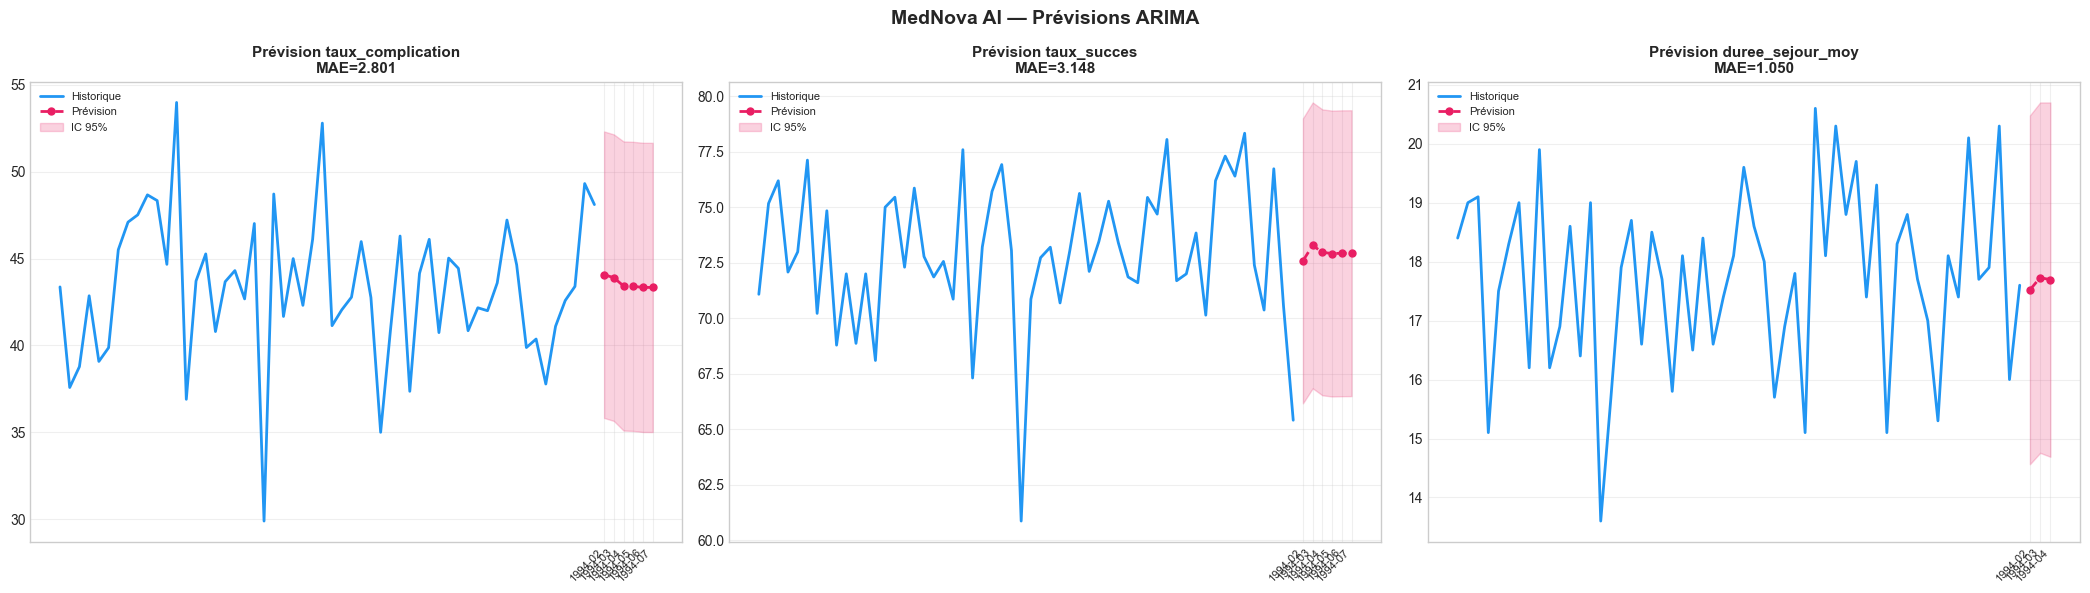

   📊 04_forecasting.png


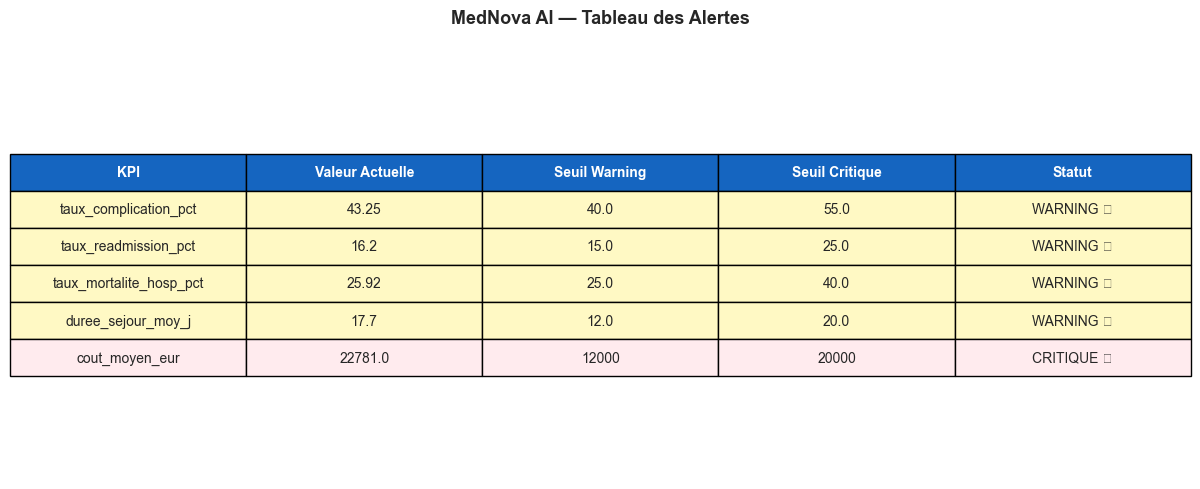

   📊 05_alertes.png


In [33]:
# SECTION 8 : Visualisations BI
# ─────────────────────────────────────────────────────────────────────────────
print('\n📊 Génération des visualisations...')

# ── Figure 1 : KPIs globaux
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

kpi_display = [
    ('taux_succes_pct',        'Taux de Succès (%)',        '#4CAF50'),
    ('taux_complication_pct',  'Taux Complications (%)',    '#E91E63'),
    ('taux_readmission_pct',   'Taux Réadmission (%)',      '#FF9800'),
    ('duree_sejour_moy_j',     'Durée Séjour Moy. (j)',     '#2196F3'),
    ('cout_moyen_eur',         'Coût Moyen (€)',            '#9C27B0'),
    ('taux_mortalite_hosp_pct','Mortalité Hospitalière (%)', '#F44336'),
]

for ax, (kpi, label, color) in zip(axes, kpi_display):
    val = global_kpis.get(kpi, 0) or 0
    ax.barh(['Global'], [val], color=color, alpha=0.8, height=0.4)
    ax.set_xlim(0, max(val * 1.4, 1))
    ax.text(val + val*0.03, 0, f'{val:,.1f}', va='center',
            fontsize=14, fontweight='bold', color=color)
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_yticks([])
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('MedNova AI — Semaine 5 | KPIs Globaux', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, '00_kpis_globaux.png'), dpi=150, bbox_inches='tight')
plt.show()
print('   📊 00_kpis_globaux.png')

# ── Figure 2 : KPIs par pathologie
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

paths   = [p['pathologie'][:20] for p in kpis_path]
compls  = [p['taux_complication_pct'] for p in kpis_path]
durees  = [p['duree_sejour_moy_j'] for p in kpis_path]
colors  = ['#F44336' if c > 50 else '#FF9800' if c > 40 else '#4CAF50' for c in compls]

bars = axes[0].barh(paths, compls, color=colors, edgecolor='white', lw=1.5)
for bar, v in zip(bars, compls):
    axes[0].text(v + 0.3, bar.get_y()+bar.get_height()/2,
                 f'{v:.1f}%', va='center', fontsize=9, fontweight='bold')
axes[0].set(xlabel='Taux Complications (%)', title='Complications par Pathologie')
axes[0].axvline(ALERT_THRESHOLDS['taux_complication_pct']['warning'],
                color='#FF9800', linestyle='--', lw=1.5, label='Seuil warning')
axes[0].axvline(ALERT_THRESHOLDS['taux_complication_pct']['critical'],
                color='#F44336', linestyle='--', lw=1.5, label='Seuil critique')
axes[0].legend(fontsize=8)

bars2 = axes[1].barh(paths, durees, color='#2196F3', edgecolor='white', lw=1.5)
for bar, v in zip(bars2, durees):
    axes[1].text(v + 0.1, bar.get_y()+bar.get_height()/2,
                 f'{v:.1f}j', va='center', fontsize=9, fontweight='bold')
axes[1].set(xlabel='Durée Séjour Moyenne (jours)', title='Durée Séjour par Pathologie')

plt.suptitle('MedNova AI — KPIs par Pathologie', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, '01_kpis_pathologie.png'), dpi=150, bbox_inches='tight')
plt.show()
print('   📊 01_kpis_pathologie.png')

# ── Figure 3 : KPIs par âge
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
age_groups = [a['age_group'] for a in kpis_age]
age_compls = [a['taux_complication_pct'] for a in kpis_age]
age_durees = [a['duree_sejour_moy_j'] for a in kpis_age]

axes[0].plot(age_groups, age_compls, color='#E91E63', lw=2.5,
             marker='o', markersize=8)
for x, y in zip(age_groups, age_compls):
    axes[0].text(x, y+0.5, f'{y:.1f}%', ha='center', fontsize=10, fontweight='bold')
axes[0].set(xlabel='Tranche d\'âge', ylabel='Taux Complications (%)',
            title='Complications par Tranche d\'Âge')
axes[0].fill_between(range(len(age_groups)), age_compls,
                     alpha=0.15, color='#E91E63')

axes[1].bar(age_groups, age_durees, color='#2196F3', edgecolor='white', lw=1.5)
for i, v in enumerate(age_durees):
    axes[1].text(i, v+0.1, f'{v:.1f}j', ha='center', fontsize=10, fontweight='bold')
axes[1].set(xlabel='Tranche d\'âge', ylabel='Durée Séjour (j)',
            title='Durée Séjour par Tranche d\'Âge')

plt.suptitle('MedNova AI — Analyse par Âge', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, '02_kpis_age.png'), dpi=150, bbox_inches='tight')
plt.show()
print('   📊 02_kpis_age.png')

# ── Figure 4 : Évolution mensuelle
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

x_months = range(len(monthly_df))
x_labels = monthly_df['mois_admission'].tolist()
step      = max(1, len(x_labels) // 12)

axes[0].plot(x_months, monthly_df['taux_complication'],
             color='#E91E63', lw=2, label='Taux complications (%)')
axes[0].fill_between(x_months, monthly_df['taux_complication'],
                     alpha=0.15, color='#E91E63')
axes[0].axhline(ALERT_THRESHOLDS['taux_complication_pct']['warning'],
                color='#FF9800', linestyle='--', lw=1.5, label='Seuil warning')
axes[0].axhline(ALERT_THRESHOLDS['taux_complication_pct']['critical'],
                color='#F44336', linestyle='--', lw=1.5, label='Seuil critique')
axes[0].set(ylabel='Taux Complications (%)', title='Évolution Mensuelle — Taux Complications')
axes[0].set_xticks(x_months[::step])
axes[0].set_xticklabels(x_labels[::step], rotation=45, ha='right', fontsize=8)
axes[0].legend()

axes[1].plot(x_months, monthly_df['duree_sejour_moy'],
             color='#2196F3', lw=2, label='Durée séjour (j)')
axes[1].fill_between(x_months, monthly_df['duree_sejour_moy'],
                     alpha=0.15, color='#2196F3')
axes[1].set(ylabel='Durée Séjour (j)', title='Évolution Mensuelle — Durée de Séjour')
axes[1].set_xticks(x_months[::step])
axes[1].set_xticklabels(x_labels[::step], rotation=45, ha='right', fontsize=8)
axes[1].legend()

plt.suptitle('MedNova AI — Semaine 5 | Évolution Temporelle', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, '03_evolution_mensuelle.png'), dpi=150, bbox_inches='tight')
plt.show()
print('   📊 03_evolution_mensuelle.png')

# ── Figure 5 : Prévisions ARIMA
if forecasts:
    n_fc = len(forecasts)
    fig, axes = plt.subplots(1, n_fc, figsize=(7*n_fc, 6))
    if n_fc == 1:
        axes = [axes]

    for ax, (kpi_col, fc) in zip(axes, forecasts.items()):
        hist_x   = list(range(len(fc['historique'])))
        prev_x   = list(range(len(fc['historique']),
                              len(fc['historique']) + fc['n_forecast']))

        ax.plot(hist_x, fc['historique'], color='#2196F3', lw=2, label='Historique')
        ax.plot(prev_x, fc['previsions'], color='#E91E63', lw=2,
                linestyle='--', marker='o', markersize=5, label='Prévision')
        ax.fill_between(prev_x, fc['conf_int_low'], fc['conf_int_high'],
                        alpha=0.2, color='#E91E63', label='IC 95%')

        # Labels des mois futurs
        ax.set_xticks(prev_x)
        ax.set_xticklabels(fc['mois_prevus'], rotation=45, ha='right', fontsize=8)

        ax.set_title(f'Prévision {kpi_col}\nMAE={fc["mae"]:.3f}',
                     fontsize=11, fontweight='bold')
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

    plt.suptitle('MedNova AI — Prévisions ARIMA', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUTS_DIR, '04_forecasting.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('   📊 04_forecasting.png')

# ── Figure 6 : Alertes dashboard
fig, ax = plt.subplots(figsize=(12, 5))
ax.axis('off')

alert_data = [[a['kpi'], str(a['valeur']),
               str(a['seuil_warning']), str(a['seuil_critical']),
               a['niveau']] for a in alerts]
col_labels = ['KPI', 'Valeur Actuelle', 'Seuil Warning', 'Seuil Critique', 'Statut']

table = ax.table(cellText=alert_data, colLabels=col_labels,
                 cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 2)

# Colorier selon statut
for i, a in enumerate(alerts):
    color = '#ffebee' if 'CRITIQUE' in a['niveau'] else \
            '#fff9c4' if 'WARNING' in a['niveau'] else '#e8f5e9'
    for j in range(5):
        table[i+1, j].set_facecolor(color)

# Header
for j in range(5):
    table[0, j].set_facecolor('#1565C0')
    table[0, j].set_text_props(color='white', fontweight='bold')

ax.set_title('MedNova AI — Tableau des Alertes', fontsize=13,
             fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, '05_alertes.png'), dpi=150, bbox_inches='tight')
plt.show()
print('   📊 05_alertes.png')

# ─────────────────────────────────────────────────────────────────────────────

---
## 🆕 Section 11 — Graphiques Interactifs (Plotly)
> Zoomables · Hover · Animations — remplacent les matplotlib statiques

In [34]:
# Installation Plotly si nécessaire
import subprocess, sys
try:
    import plotly
except ImportError:
    subprocess.check_call([sys.executable,'-m','pip','install','plotly','-q'],
                          stdout=subprocess.DEVNULL,stderr=subprocess.DEVNULL)
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
print('✅ Plotly', __import__('plotly').__version__)

✅ Plotly 6.6.0


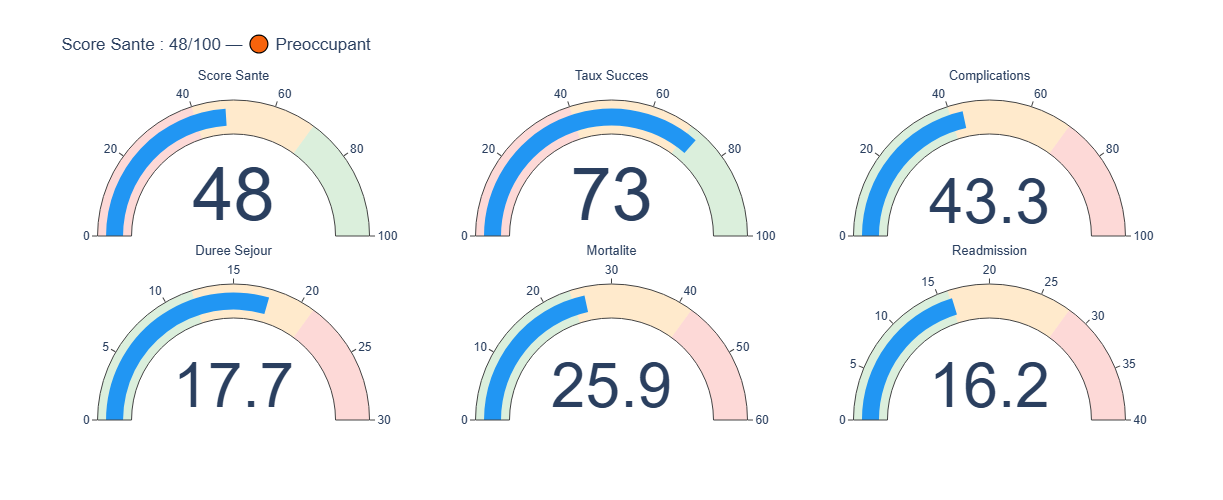

Score Sante Hopital : 48/100 — 🟠 Preoccupant


In [35]:
# ── Gauge Charts : Score Sante + KPIs
fig_gauges = make_subplots(
    rows=2, cols=3,
    specs=[[{'type':'indicator'}]*3,[{'type':'indicator'}]*3],
    vertical_spacing=0.15)

HEALTH_SCORE = max(0,min(100,100-sum(
    20 if (v:=global_kpis.get(k,0)) is not None and v>=thr['critical'] else
    8  if v is not None and v>=thr['warning'] else 0
    for k,thr in ALERT_THRESHOLDS.items())))
HEALTH_LABEL = ('🟢 Excellent' if HEALTH_SCORE>=80 else
                '🟡 Satisfaisant' if HEALTH_SCORE>=60 else
                '🟠 Preoccupant' if HEALTH_SCORE>=40 else '🔴 Critique')

gauges = [
    ('Score Sante',  HEALTH_SCORE, 0, 100, ['#F44336','#FF9800','#4CAF50']),
    ('Taux Succes',  global_kpis['taux_succes_pct'], 0, 100, ['#F44336','#FF9800','#4CAF50']),
    ('Complications',global_kpis['taux_complication_pct'], 0, 100, ['#4CAF50','#FF9800','#F44336']),
    ('Duree Sejour', global_kpis['duree_sejour_moy_j'], 0, 30, ['#4CAF50','#FF9800','#F44336']),
    ('Mortalite',    global_kpis['taux_mortalite_hosp_pct'], 0, 60, ['#4CAF50','#FF9800','#F44336']),
    ('Readmission',  global_kpis['taux_readmission_pct'], 0, 40, ['#4CAF50','#FF9800','#F44336']),
]
for (title,val,vmin,vmax,colors),(r,c) in zip(gauges,[(1,1),(1,2),(1,3),(2,1),(2,2),(2,3)]):
    sp = vmax-vmin
    fig_gauges.add_trace(go.Indicator(
        mode='gauge+number', value=val,
        title={'text':title,'font':{'size':13}},
        gauge={'axis':{'range':[vmin,vmax]},'bar':{'color':'#2196F3'},
               'steps':[
                   {'range':[vmin,vmin+sp*0.4],'color':'rgba({},{},{},0.2)'.format(int(colors[0][1:3],16),int(colors[0][3:5],16),int(colors[0][5:7],16))},
                   {'range':[vmin+sp*0.4,vmin+sp*0.7],'color':'rgba({},{},{},0.2)'.format(int(colors[1][1:3],16),int(colors[1][3:5],16),int(colors[1][5:7],16))},
                   {'range':[vmin+sp*0.7,vmax],'color':'rgba({},{},{},0.2)'.format(int(colors[2][1:3],16),int(colors[2][3:5],16),int(colors[2][5:7],16))}
               ]}
    ), row=r, col=c)
fig_gauges.update_layout(
    title_text=f'Score Sante : {HEALTH_SCORE}/100 — {HEALTH_LABEL}',
    height=500, paper_bgcolor='white', font={'family':'Arial'})
fig_gauges.show()
print(f'Score Sante Hopital : {HEALTH_SCORE}/100 — {HEALTH_LABEL}')

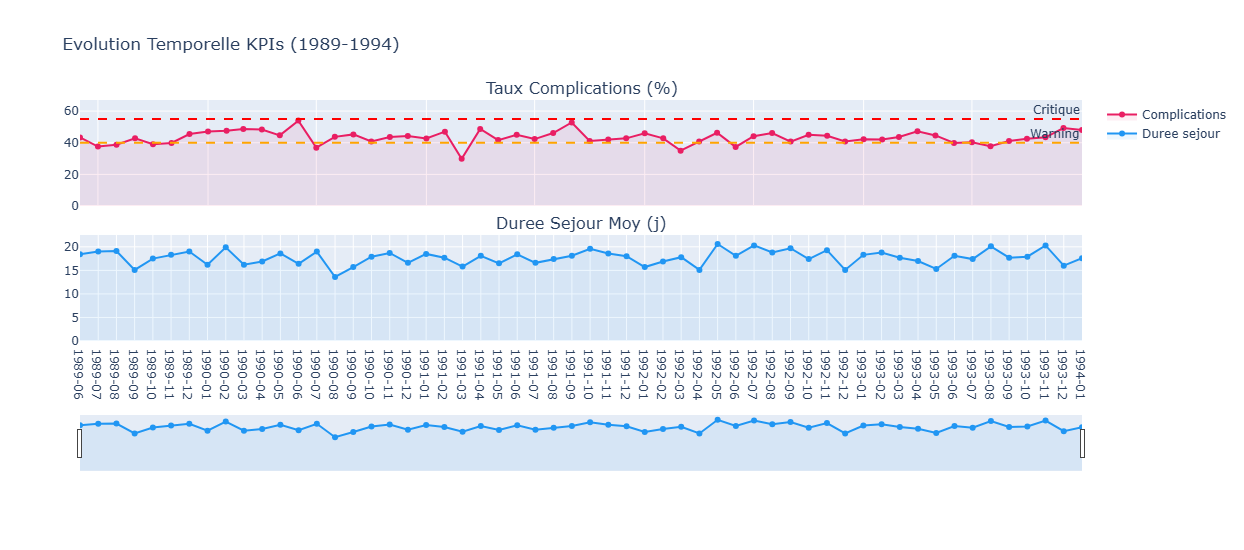

In [36]:
# ── Evolution temporelle interactive avec range slider
fig_time = make_subplots(rows=2, cols=1, shared_xaxes=True,
    subplot_titles=['Taux Complications (%)','Duree Sejour Moy (j)'],
    vertical_spacing=0.12)
months = monthly_df['mois_admission'].tolist()
fig_time.add_trace(go.Scatter(x=months, y=monthly_df['taux_complication'],
    mode='lines+markers', name='Complications', line={'color':'#E91E63','width':2},
    fill='tozeroy', fillcolor='rgba(233,30,99,0.08)',
    hovertemplate='%{x}<br>Complications: %{y:.1f}%<extra></extra>'), row=1, col=1)
fig_time.add_hline(y=ALERT_THRESHOLDS['taux_complication_pct']['warning'],
    line_dash='dash', line_color='orange', annotation_text='Warning', row=1, col=1)
fig_time.add_hline(y=ALERT_THRESHOLDS['taux_complication_pct']['critical'],
    line_dash='dash', line_color='red', annotation_text='Critique', row=1, col=1)
fig_time.add_trace(go.Scatter(x=months, y=monthly_df['duree_sejour_moy'],
    mode='lines+markers', name='Duree sejour', line={'color':'#2196F3','width':2},
    fill='tozeroy', fillcolor='rgba(33,150,243,0.08)',
    hovertemplate='%{x}<br>Duree: %{y:.1f}j<extra></extra>'), row=2, col=1)
fig_time.update_layout(title_text='Evolution Temporelle KPIs (1989-1994)',
    height=550, hovermode='x unified', paper_bgcolor='white',
    xaxis2={'rangeslider':{'visible':True},'type':'category'})
fig_time.show()

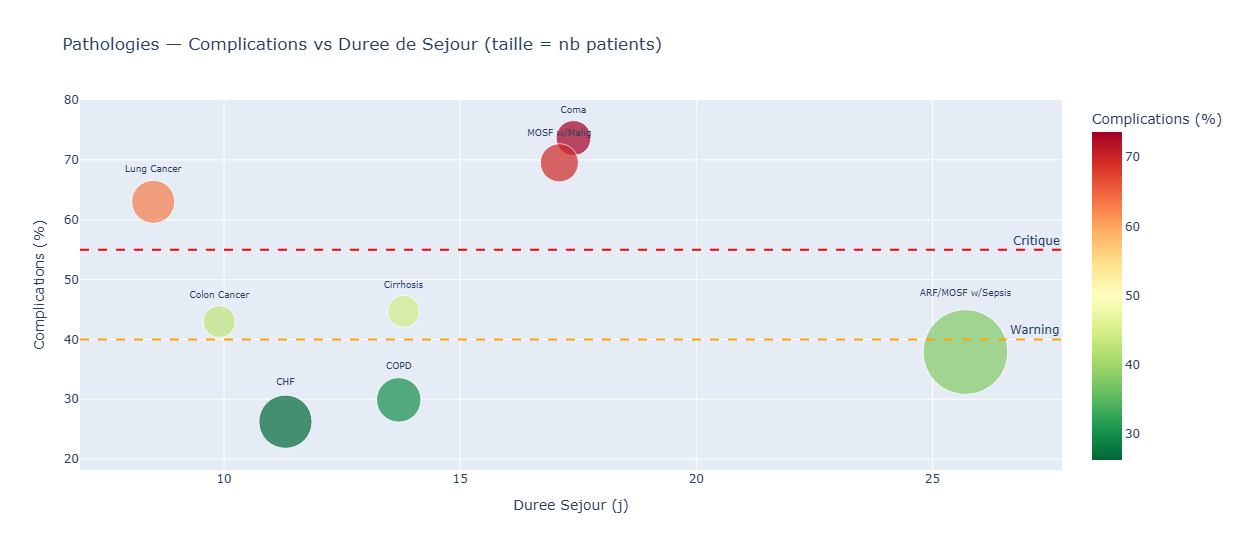

In [37]:
# ── Bubble Chart pathologies : complications vs duree vs cout
path_df = pd.DataFrame(kpis_path)
fig_b = px.scatter(path_df,
    x='duree_sejour_moy_j', y='taux_complication_pct',
    size='n_patients', color='taux_complication_pct',
    color_continuous_scale='RdYlGn_r',
    hover_name='pathologie', hover_data={'cout_moyen_eur':True,'n_patients':True},
    text='pathologie', size_max=60,
    title='Pathologies — Complications vs Duree de Sejour (taille = nb patients)',
    labels={'duree_sejour_moy_j':'Duree Sejour (j)','taux_complication_pct':'Complications (%)'})
fig_b.update_traces(textposition='top center', textfont_size=9)
fig_b.add_hline(y=ALERT_THRESHOLDS['taux_complication_pct']['warning'],
    line_dash='dash', line_color='orange', annotation_text='Warning')
fig_b.add_hline(y=ALERT_THRESHOLDS['taux_complication_pct']['critical'],
    line_dash='dash', line_color='red', annotation_text='Critique')
fig_b.update_layout(height=550, paper_bgcolor='white')
fig_b.show()

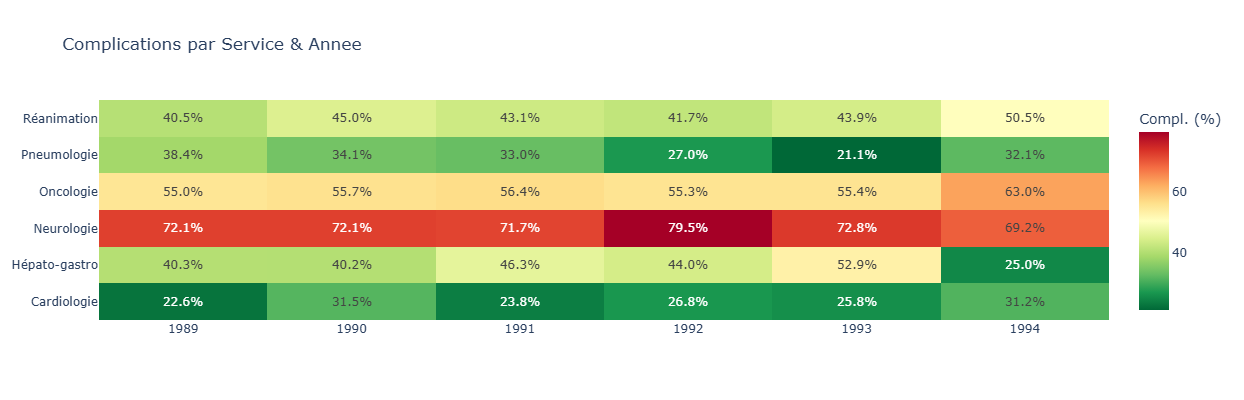

In [38]:
# ── Heatmap service x annee
sy = df.groupby(['service','annee_admission'])['complication'].mean().reset_index()
sy['complication'] = (sy['complication']*100).round(1)
pivot = sy.pivot(index='service', columns='annee_admission', values='complication')
fig_h = go.Figure(data=go.Heatmap(
    z=pivot.values, x=[str(c) for c in pivot.columns], y=pivot.index.tolist(),
    colorscale='RdYlGn_r',
    text=[[f'{v:.1f}%' for v in row] for row in pivot.values],
    texttemplate='%{text}',
    hovertemplate='Service: %{y}<br>Annee: %{x}<br>Complications: %{z:.1f}%<extra></extra>',
    colorbar={'title':'Compl. (%)'}))
fig_h.update_layout(title_text='Complications par Service & Annee',
    height=400, paper_bgcolor='white')
fig_h.show()

---
## 🆕 Section 12 — Système d'Alertes Avancé
> Score Santé 0-100 · Tendances · Recommandations automatiques

In [39]:
# Alertes avancées avec tendances et recommandations
ALERT_RECO = {
    'taux_complication_pct'  : {
        'warning' :'Renforcer les protocoles de surveillance clinique',
        'critical':'Audit immediat des services — comite de crise'},
    'taux_mortalite_hosp_pct': {
        'warning' :'Reviser les protocoles soins intensifs',
        'critical':'Activation du plan urgence hospitalier'},
    'duree_sejour_moy_j'     : {
        'warning' :'Optimiser les sorties anticipees et la coordination',
        'critical':'Revoir gestion des lits — risque engorgement'},
    'taux_readmission_pct'   : {
        'warning' :'Ameliorer le suivi post-hospitalisation',
        'critical':'Programme urgent de suivi ambulatoire'},
    'cout_moyen_eur'         : {
        'warning' :'Analyser les postes de depenses les plus eleves',
        'critical':'Plan de reduction des couts — audit financier'},
}
KPI_MONTHLY_MAP = {
    'taux_complication_pct':'taux_complication',
    'duree_sejour_moy_j':'duree_sejour_moy',
}

def compute_trend(monthly, col, n=3):
    if col not in monthly.columns or len(monthly)<n+1: return 'stable',0.0
    recent = monthly[col].tail(n).values
    older  = monthly[col].tail(n*2).head(n).values
    if len(older)==0: return 'stable',0.0
    pct = round((recent.mean()-older.mean())/(older.mean()+1e-9)*100,1)
    if pct>5:  return '📈 Hausse',pct
    if pct<-5: return '📉 Baisse',pct
    return '➡️ Stable',pct

def check_alerts_v2(kpis, monthly, thresholds=ALERT_THRESHOLDS, recos=ALERT_RECO):
    alerts = []
    for kpi,val in kpis.items():
        if kpi not in thresholds or val is None: continue
        thr = thresholds[kpi]
        if   val>=thr['critical']: niveau,score = 'CRITIQUE 🔴',3
        elif val>=thr['warning']:  niveau,score = 'WARNING  🟡',2
        else:                      niveau,score = 'OK       🟢',1
        mc = KPI_MONTHLY_MAP.get(kpi)
        tend,dp = compute_trend(monthly,mc) if mc else ('N/A',0)
        rk = recos.get(kpi,{})
        reco = rk.get('critical' if score==3 else 'warning','Indicateur dans les normes') if score>=2 else 'Indicateur dans les normes'
        alerts.append({'kpi':kpi,'valeur':val,'niveau':niveau,'score':score,
                        'tendance':tend,'delta_pct':dp,'recommandation':reco,
                        'seuil_warning':thr['warning'],'seuil_critical':thr['critical']})
    return sorted(alerts,key=lambda x:-x['score'])

alerts_v2 = check_alerts_v2(global_kpis, monthly_df)

print('='*65)
print(f'  SCORE SANTE HOPITAL : {HEALTH_SCORE}/100 — {HEALTH_LABEL}')
print('='*65)
print(f'  {"KPI":<35} {"Valeur":>10}  {"Statut":<15} {"Tendance"}')
print('  '+'-'*72)
for a in alerts_v2:
    print(f'  {a["kpi"]:<35} {str(a["valeur"]):>10}  {a["niveau"]:<15} {a["tendance"]}')
print('\nRECOMMANDATIONS :')
for a in [x for x in alerts_v2 if x['score']>=2]:
    icon = '🔴' if a['score']==3 else '🟡'
    print(f'  {icon} {a["kpi"]}')
    print(f'     → {a["recommandation"]}')

  SCORE SANTE HOPITAL : 48/100 — 🟠 Preoccupant
  KPI                                     Valeur  Statut          Tendance
  ------------------------------------------------------------------------
  cout_moyen_eur                         22781.0  CRITIQUE 🔴      N/A
  taux_complication_pct                    43.25  WARNING  🟡      📈 Hausse
  taux_readmission_pct                      16.2  WARNING  🟡      N/A
  taux_mortalite_hosp_pct                  25.92  WARNING  🟡      N/A
  duree_sejour_moy_j                        17.7  WARNING  🟡      ➡️ Stable

RECOMMANDATIONS :
  🔴 cout_moyen_eur
     → Plan de reduction des couts — audit financier
  🟡 taux_complication_pct
     → Renforcer les protocoles de surveillance clinique
  🟡 taux_readmission_pct
     → Ameliorer le suivi post-hospitalisation
  🟡 taux_mortalite_hosp_pct
     → Reviser les protocoles soins intensifs
  🟡 duree_sejour_moy_j
     → Optimiser les sorties anticipees et la coordination


---
## 🆕 Section 13 — Innovations Originales

### 3 features qui différencient le projet

In [40]:
# ── INNOVATION 1 : Fiches cliniques automatiques par pathologie
def clinical_brief(patho, data):
    grp = data[data['dzgroup']==patho] if 'dzgroup' in data.columns else pd.DataFrame()
    if len(grp)==0: return None
    cr = grp['complication'].mean()*100
    return {
        'patho':patho, 'n':len(grp),
        'icon':'🔴' if cr>55 else '🟠' if cr>40 else '🟢',
        'compl':round(cr,1),
        'age':round(grp['age'].mean(),1),
        'duree':round(grp['duree_sejour'].mean(),1),
        'cout':round(grp['cout_estime'].mean(),0),
        'mort':round(grp['hospdead'].mean()*100,1) if 'hospdead' in grp.columns else 0,
        'age_dom':str(grp['age_group'].mode()[0]) if 'age_group' in grp.columns and len(grp['age_group'].dropna())>0 else 'N/A',
    }

print('='*65)
print('  FICHES CLINIQUES AUTOMATIQUES — Top 3 pathologies')
print('='*65)
top3 = [p['pathologie'] for p in kpis_path[:3]]
for patho in top3:
    b = clinical_brief(patho, df)
    if b:
        print(f'\n  {b["icon"]} {b["patho"]}')
        print(f'  ├─ Patients      : {b["n"]:,} ({b["n"]/len(df)*100:.1f}% du total)')
        print(f'  ├─ Complications  : {b["compl"]}%')
        print(f'  ├─ Age moyen     : {b["age"]} ans (profil dominant: {b["age_dom"]})')
        print(f'  ├─ Duree sejour  : {b["duree"]} jours')
        print(f'  ├─ Cout moyen    : {b["cout"]:,.0f} EUR')
        print(f'  └─ Mortalite     : {b["mort"]}%')
print('='*65)

  FICHES CLINIQUES AUTOMATIQUES — Top 3 pathologies

  🔴 Coma
  ├─ Patients      : 596 (6.5% du total)
  ├─ Complications  : 73.7%
  ├─ Age moyen     : 64.9 ans (profil dominant: 75+)
  ├─ Duree sejour  : 17.4 jours
  ├─ Cout moyen    : 21,855 EUR
  └─ Mortalite     : 60.7%

  🔴 MOSF w/Malig
  ├─ Patients      : 712 (7.8% du total)
  ├─ Complications  : 69.5%
  ├─ Age moyen     : 58.4 ans (profil dominant: 40-55)
  ├─ Duree sejour  : 17.1 jours
  ├─ Cout moyen    : 21,856 EUR
  └─ Mortalite     : 52.7%

  🔴 Lung Cancer
  ├─ Patients      : 908 (10.0% du total)
  ├─ Complications  : 63.0%
  ├─ Age moyen     : 62.0 ans (profil dominant: 55-65)
  ├─ Duree sejour  : 8.5 jours
  ├─ Cout moyen    : 11,405 EUR
  └─ Mortalite     : 11.2%


In [41]:
# ── INNOVATION 2 : Rapport Executif Narratif Auto
def executive_report(kpis, alerts, forecasts, services):
    nc = sum(1 for a in alerts if a['score']==3)
    nw = sum(1 for a in alerts if a['score']==2)
    best  = min(services, key=lambda x: x['taux_complication_pct'])
    worst = max(services, key=lambda x: x['taux_complication_pct'])
    fc_c  = forecasts.get('taux_complication',{})
    tend  = ''
    if fc_c:
        cur = kpis['taux_complication_pct']; fut = fc_c['previsions'][-1]
        tend = f'en hausse vers {fut:.1f}%' if fut>cur else f'en baisse vers {fut:.1f}%'
    recos = [a['recommandation'] for a in alerts if a['score']>=2][:3]
    sep = '-'*50
    lines = [
        '',f'  RAPPORT EXECUTIF MEDNOVA AI BI',f'  {sep}',
        f'  Taux de succes   : {kpis["taux_succes_pct"]}%',
        f'  Complications    : {kpis["taux_complication_pct"]}%',
        f'  Duree de sejour  : {kpis["duree_sejour_moy_j"]} jours',
        f'  Cout moyen       : {kpis["cout_moyen_eur"]:,.0f} EUR',
        f'  Population       : {kpis["n_patients"]:,} patients',
        f'  {sep}',
        f'  Alertes : {nc} CRITIQUE | {nw} WARNING',
        f'  {"⚠️ ACTION REQUISE IMMEDIATEMENT" if nc>0 else "✅ Situation globalement maitrisee"}',
        f'  {sep}',
        f'  Meilleur service : {best["service"]} ({best["taux_complication_pct"]}%)',
        f'  Service a risque : {worst["service"]} ({worst["taux_complication_pct"]}%)',
        f'  Ecart            : {worst["taux_complication_pct"]-best["taux_complication_pct"]:.1f} points',
        f'  {sep}',
        f'  Tendance ARIMA   : {tend if tend else "stable sur 6 mois"}',
        '',f'  RECOMMANDATIONS :',
    ]
    for i,r in enumerate(recos,1): lines.append(f'  {i}. {r}')
    return '\n'.join(lines)

print(executive_report(global_kpis, alerts_v2, forecasts, kpis_service))


  RAPPORT EXECUTIF MEDNOVA AI BI
  --------------------------------------------------
  Taux de succes   : 72.95%
  Complications    : 43.25%
  Duree de sejour  : 17.7 jours
  Cout moyen       : 22,781 EUR
  Population       : 9,105 patients
  --------------------------------------------------
  Alertes : 1 CRITIQUE | 4 WARNING
  ⚠️ ACTION REQUISE IMMEDIATEMENT
  --------------------------------------------------
  Meilleur service : Cardiologie (26.24%)
  Service a risque : Neurologie (73.66%)
  Ecart            : 47.4 points
  --------------------------------------------------
  Tendance ARIMA   : en hausse vers 43.3%

  RECOMMANDATIONS :
  1. Plan de reduction des couts — audit financier
  2. Renforcer les protocoles de surveillance clinique
  3. Ameliorer le suivi post-hospitalisation


Detection anomalies temporelles (z-score > 2.0) :

  Taux Complications — 4 mois anormaux detectes :
     🔵 1991-03 : 29.9 (z=3.23)
     🔴 1990-06 : 54.0 (z=2.57)
     🔴 1991-09 : 52.8 (z=2.28)

  Duree Sejour — 1 mois anormaux detectes :
     🔵 1990-08 : 13.6 (z=2.73)


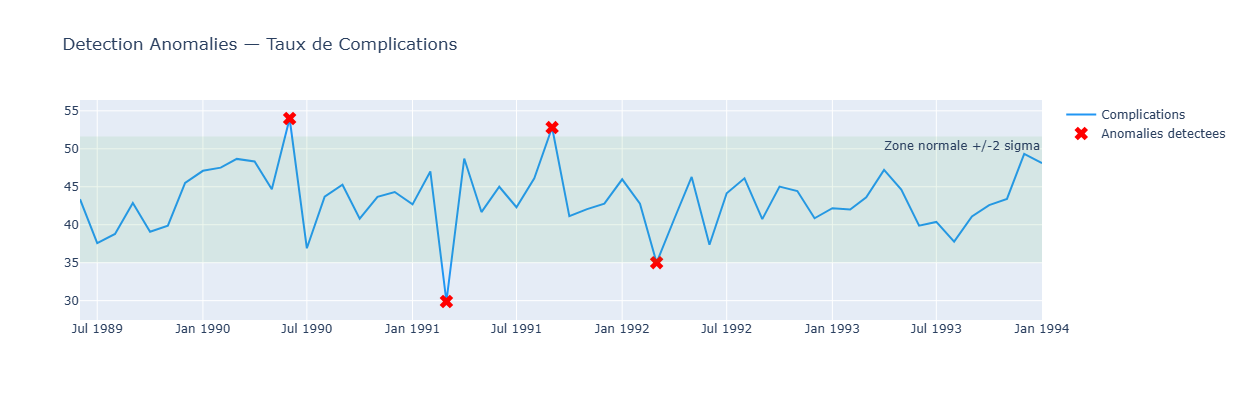

In [42]:
# ── INNOVATION 3 : Detection d'anomalies temporelles (z-score)
def detect_anomalies(monthly_data, col, z_thr=2.0):
    vals = monthly_data[col].values
    mean, std = vals.mean(), vals.std()
    z    = np.abs((vals-mean)/(std+1e-9))
    mask = z>z_thr
    r    = monthly_data[mask][['mois_admission',col]].copy()
    r['z_score'] = z[mask]
    r['type']    = r[col].apply(lambda x:'Pic anormal' if x>mean else 'Creux anormal')
    return r.sort_values('z_score',ascending=False)

print('Detection anomalies temporelles (z-score > 2.0) :')
print('='*55)
for col,label in [('taux_complication','Taux Complications'),('duree_sejour_moy','Duree Sejour')]:
    anom = detect_anomalies(monthly_df, col)
    print(f'\n  {label} — {len(anom)} mois anormaux detectes :')
    for _,row in anom.head(3).iterrows():
        icon = '🔴' if row['type']=='Pic anormal' else '🔵'
        print(f'     {icon} {row["mois_admission"]} : {row[col]:.1f} (z={row["z_score"]:.2f})')
    if len(anom)==0: print('     Aucune anomalie detectee')

# Visualisation Plotly anomalies
vals   = monthly_df['taux_complication'].values
months = monthly_df['mois_admission'].tolist()
mean_v = vals.mean(); std_v = vals.std()
fig_an = go.Figure()
fig_an.add_trace(go.Scatter(x=months, y=vals, mode='lines', name='Complications',
    line={'color':'#2196F3','width':2}))
fig_an.add_hrect(y0=mean_v-2*std_v, y1=mean_v+2*std_v,
    fillcolor='rgba(76,175,80,0.1)', line_width=0,
    annotation_text='Zone normale +/-2 sigma')
anom_c = detect_anomalies(monthly_df,'taux_complication')
if len(anom_c)>0:
    anom_vals = [float(monthly_df[monthly_df['mois_admission']==m]['taux_complication'].values[0])
                 if m in months else None for m in anom_c['mois_admission']]
    fig_an.add_trace(go.Scatter(x=list(anom_c['mois_admission']), y=anom_vals,
        mode='markers', name='Anomalies detectees',
        marker={'color':'red','size':12,'symbol':'x'}))
fig_an.update_layout(title='Detection Anomalies — Taux de Complications',
    height=400, paper_bgcolor='white', hovermode='x')
fig_an.show()

---
## 🆕 Section 14 — Score Santé Global (Dashboard Synthèse)
> Vue d'ensemble pour la direction

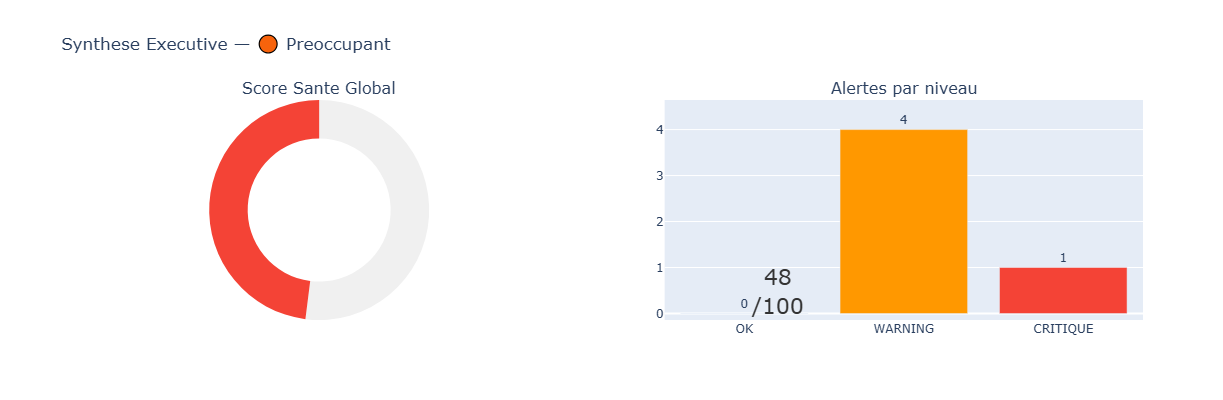


SCORE SANTE FINAL : 48/100 — 🟠 Preoccupant
Critiques : 1 | Warnings : 4 | OK : 0


In [43]:
# Dashboard synthese final — Plotly
fig_synth = make_subplots(rows=1, cols=2,
    specs=[[{'type':'domain'},{'type':'xy'}]],
    subplot_titles=['Score Sante Global','Alertes par niveau'])

# Pie score
colors_score = ['#4CAF50','#FF9800','#F44336']
fig_synth.add_trace(go.Pie(
    labels=['Score','Manquant'],
    values=[HEALTH_SCORE, 100-HEALTH_SCORE],
    hole=0.65,
    marker_colors=[('#4CAF50' if HEALTH_SCORE>=80 else '#FF9800' if HEALTH_SCORE>=60 else '#F44336'),'#f0f0f0'],
    textinfo='none',
    hovertemplate=f'Score: {HEALTH_SCORE}/100<extra></extra>',
    showlegend=False
), row=1, col=1)
fig_synth.add_annotation(text=f'{HEALTH_SCORE}<br>/100', x=0.21, y=0.5,
    font={'size':22,'color':'#333'}, showarrow=False)

# Barres alertes
levels   = ['OK','WARNING','CRITIQUE']
counts_a = [sum(1 for a in alerts_v2 if a['score']==s) for s in [1,2,3]]
colors_a = ['#4CAF50','#FF9800','#F44336']
fig_synth.add_trace(go.Bar(x=levels, y=counts_a, marker_color=colors_a,
    text=counts_a, textposition='outside',
    hovertemplate='%{x}: %{y} indicateur(s)<extra></extra>'), row=1, col=2)

fig_synth.update_layout(title_text=f'Synthese Executive — {HEALTH_LABEL}',
    height=400, paper_bgcolor='white', showlegend=False)
fig_synth.show()

print(f'\nSCORE SANTE FINAL : {HEALTH_SCORE}/100 — {HEALTH_LABEL}')
print(f'Critiques : {counts_a[2]} | Warnings : {counts_a[1]} | OK : {counts_a[0]}')

## 📄 Section 9 — Export JSON Frontend

In [44]:
# SECTION 9 : Export JSON pour le frontend
# ─────────────────────────────────────────────────────────────────────────────
# ── Serializer JSON robuste pour numpy types
class NumpyEncoder(json.JSONEncoder):
    def default(self, obj):
        import numpy as np
        if isinstance(obj, (np.integer,)):  return int(obj)
        if isinstance(obj, (np.floating,)): return float(obj)
        if isinstance(obj, np.ndarray):     return obj.tolist()
        return super().default(obj)

def json_dump(obj, fp, **kwargs):
    json.dump(obj, fp, cls=NumpyEncoder, **kwargs)

print('\n🔵 Export JSON pour le frontend...')

# ── 1. kpis_global.json
kpis_global_json = {
    'metadata'  : {'data_source': DATA_SOURCE, 'n_patients': len(df)},
    'global'    : global_kpis,
    'alerts'    : alerts,
    'thresholds': ALERT_THRESHOLDS,
}
with open(os.path.join(JSON_DIR, 'kpis_global.json'), 'w', encoding='utf-8') as f:
    json_dump(kpis_global_json, f, ensure_ascii=False, indent=2)
print('   ✅ kpis_global.json')

# ── 2. kpis_pathologie.json
with open(os.path.join(JSON_DIR, 'kpis_pathologie.json'), 'w', encoding='utf-8') as f:
    json_dump({'pathologies': kpis_path}, f, ensure_ascii=False, indent=2)
print('   ✅ kpis_pathologie.json')

# ── 3. kpis_service.json
with open(os.path.join(JSON_DIR, 'kpis_service.json'), 'w', encoding='utf-8') as f:
    json_dump({'services': kpis_service}, f, ensure_ascii=False, indent=2)
print('   ✅ kpis_service.json')

# ── 4. kpis_age.json
with open(os.path.join(JSON_DIR, 'kpis_age.json'), 'w', encoding='utf-8') as f:
    json_dump({'age_groups': kpis_age}, f, ensure_ascii=False, indent=2)
print('   ✅ kpis_age.json')

# ── 5. kpis_monthly.json — série temporelle complète
monthly_records = monthly_df.to_dict(orient='records')
with open(os.path.join(JSON_DIR, 'kpis_monthly.json'), 'w', encoding='utf-8') as f:
    json_dump({'monthly': monthly_records}, f, ensure_ascii=False, indent=2)
print(f'   ✅ kpis_monthly.json ({len(monthly_records)} mois)')

# ── 6. forecasts.json — prévisions ARIMA
if forecasts:
    forecasts_serializable = {}
    for k, v in forecasts.items():
        forecasts_serializable[k] = v
    with open(os.path.join(JSON_DIR, 'forecasts.json'), 'w', encoding='utf-8') as f:
        json_dump({'forecasts': forecasts_serializable}, f, ensure_ascii=False, indent=2)
    print(f'   ✅ forecasts.json ({len(forecasts)} KPIs prévus)')

# ── 7. dashboard_summary.json — résumé pour la page d'accueil React
dashboard_summary = {
    'last_updated'   : str(pd.Timestamp.now().date()),
    'data_source'    : DATA_SOURCE,
    'n_patients'     : len(df),
    'kpis_snapshot'  : {
        'taux_succes'      : global_kpis['taux_succes_pct'],
        'taux_complication': global_kpis['taux_complication_pct'],
        'duree_sejour'     : global_kpis['duree_sejour_moy_j'],
        'cout_moyen'       : global_kpis['cout_moyen_eur'],
    },
    'n_alertes_critiques': sum(1 for a in alerts if 'CRITIQUE' in a['niveau']),
    'n_alertes_warning'  : sum(1 for a in alerts if 'WARNING'  in a['niveau']),
    'services'           : [s['service'] for s in kpis_service],
    'pathologies'        : [p['pathologie'] for p in kpis_path],
}
with open(os.path.join(JSON_DIR, 'dashboard_summary.json'), 'w', encoding='utf-8') as f:
    json_dump(dashboard_summary, f, ensure_ascii=False, indent=2)
print('   ✅ dashboard_summary.json')

# ─────────────────────────────────────────────────────────────────────────────


🔵 Export JSON pour le frontend...
   ✅ kpis_global.json
   ✅ kpis_pathologie.json
   ✅ kpis_service.json
   ✅ kpis_age.json
   ✅ kpis_monthly.json (56 mois)
   ✅ forecasts.json (3 KPIs prévus)
   ✅ dashboard_summary.json


## 📋 Section 10 — Rapport Final

In [45]:
# SECTION 10 : Rapport final
# ─────────────────────────────────────────────────────────────────────────────
n_plots = len([f for f in os.listdir(OUTPUTS_DIR) if f.endswith('.png')])
n_jsons = len([f for f in os.listdir(JSON_DIR)    if f.endswith('.json')])

print('\n' + '='*65)
print('  📋 RAPPORT FINAL — MedNova AI | Semaine 5')
print('='*65)
print(f'''
📦 DATASET     : {DATA_SOURCE} | {df.shape}

📊 KPIs GLOBAUX :
   Taux succès        : {global_kpis["taux_succes_pct"]}%
   Taux complications : {global_kpis["taux_complication_pct"]}%
   Taux réadmission   : {global_kpis["taux_readmission_pct"]}%
   Durée séjour moy   : {global_kpis["duree_sejour_moy_j"]} jours
   Coût moyen         : {global_kpis["cout_moyen_eur"]} €

🚨 ALERTES :
   Critiques : {sum(1 for a in alerts if "CRITIQUE" in a["niveau"])}
   Warnings  : {sum(1 for a in alerts if "WARNING"  in a["niveau"])}
   OK        : {sum(1 for a in alerts if "OK"       in a["niveau"])}

📈 FORECASTING :''')
for kpi_col, fc in forecasts.items():
    print(f'   {kpi_col:<25} MAE={fc["mae"]:.3f} | '
          f'Prévision +{fc["n_forecast"]}m: {fc["previsions"][-1]:.2f}')

print(f'''
✅ LIVRABLES
   📊 outputs/bi/     ({n_plots} PNG)
   📄 outputs/json/   ({n_jsons} JSON total)
      kpis_global.json
      kpis_pathologie.json
      kpis_service.json
      kpis_age.json
      kpis_monthly.json
      forecasts.json
      dashboard_summary.json
''')
print('='*65)
print('\n✅ Semaine 5 — Complète! 🎉')
print('\n🚀 Prochaine étape : Semaine 6 — Alertes avancées + Rapport PDF')


  📋 RAPPORT FINAL — MedNova AI | Semaine 5

📦 DATASET     : UCI_OFFICIAL | (9105, 59)

📊 KPIs GLOBAUX :
   Taux succès        : 72.95%
   Taux complications : 43.25%
   Taux réadmission   : 16.2%
   Durée séjour moy   : 17.7 jours
   Coût moyen         : 22781.0 €

🚨 ALERTES :
   Critiques : 1
   Warnings  : 4
   OK        : 0

📈 FORECASTING :
   taux_complication         MAE=2.801 | Prévision +6m: 43.34
   taux_succes               MAE=3.148 | Prévision +6m: 72.93
   duree_sejour_moy          MAE=1.050 | Prévision +3m: 17.70

✅ LIVRABLES
   📊 outputs/bi/     (6 PNG)
   📄 outputs/json/   (11 JSON total)
      kpis_global.json
      kpis_pathologie.json
      kpis_service.json
      kpis_age.json
      kpis_monthly.json
      forecasts.json
      dashboard_summary.json


✅ Semaine 5 — Complète! 🎉

🚀 Prochaine étape : Semaine 6 — Alertes avancées + Rapport PDF
